 Binary classification NN - strategy: Make one big dataset with 0 for missing values, train weights for all N
 

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from ignite.metrics.regression import MeanAbsoluteRelativeError
from torch import manual_seed, nn, no_grad, optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

torch.manual_seed(10101010) # because we randomly sort the data inside the data loader

In [2]:
class TensorData(Dataset):
    def __init__(self, input_tensor, label_tensor):
        self.input = input_tensor
        self.labels = label_tensor

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [3]:
def load_data():
    input_data_5 = "kaggle_train_5_fences.csv"
    input_data_7 = "kaggle_train_7_fences.csv"
    input_data_9 = "kaggle_train_9_fences.csv"
    test_input = "kaggle_hidden_test_fences.csv"
    return {"input_data_5": pd.read_csv(input_data_5),"input_data_7": pd.read_csv(input_data_7),"input_data_9": pd.read_csv(input_data_9), "test_input": pd.read_csv(test_input)}

data = load_data()

#print(data["input_data_7"].head())

Fillnan and dummy values + only columns

In [4]:
def separate_inputs(data_input):
    # Initialize data array as a lst
    pure_data = []

    data = data_input
    data5 = data["input_data_5"].copy()
    data7 = data["input_data_7"].copy()
    data9 = data["input_data_9"].copy()
    data_test = data["test_input"].copy()

    # Insert dummy columns
    for n in ["8","7","6","5"]:
        data5.insert(6,n,0)

    for n in ["8","7"]:
        data7.insert(8,n,0)

    # Extract only columns
    data_new = {"data5" : data5.loc[:, ['0','1', '2',"3","4","5","6","7","8","CE"]],
                "data7" : data7.loc[:, ['0','1', '2',"3","4","5","6","7","8","CE"]],
                "data9" : data9.loc[:, ['0','1', '2',"3","4","5","6","7","8","CE"]]}

    train_df  = pd.DataFrame()
    valid_df  = pd.DataFrame()
    
    for data_set in data_new.values():

        data_nd_train = data_set.sample(frac = 0.8 , random_state=1111)
        data_nd_validate = data_set.drop(data_nd_train.index)
        
        train_df = pd.concat([train_df,data_nd_train]).reset_index(drop=True)
        valid_df = pd.concat([valid_df,data_nd_validate]).reset_index(drop=True)


    
    # Replace NaN with zeros in testing data set
    data_test = data_test.fillna(0)

    # Return data_train as pdf and data_test as an numpy array
    return train_df,valid_df, data_test.loc[:, ['0','1', '2',"3","4","5","6","7","8"]].to_numpy()

def extract_labels(input):
    # Initialize labels list
    pure_label = []

    data = input.copy()
    '''

    # Extract labels into a list
    for data_set in data.values():
        pure_label.append(data_set.loc[:,["CE"]])
     '''   
    
    # Return only labels from train data, test data contains no CE
    return np.vstack(data.loc[:,["CE"]].to_numpy())

def only_inputs(input):
    # Initialize data list
    

    data = input.copy()
    return data.loc[:, ['0','1', '2',"3","4","5","6","7","8"]]



Symmetry funcs: just permutation is fine because it is a higher order symmetry operation
  

In [5]:
"""
def cyclic_sort(data_input):
    # Set largest fence to bottom (= position 1)
    # Initialize for return
    rotated_arrs = []
    
    arr = data_input.to_numpy().copy()
        
    for i,row in enumerate(arr):
        max_index = row.argmax()
        arr[i] = np.roll(row, shift=-max_index)
            
        rotated_arrs.append(arr)
                
    return arr
    

def orientation_sort(rotated_arrs):
    values = rotated_arrs.copy()

    for idx, row in enumerate(values):
        # Extract real values (ignore padding zeros)
        real = row[row != 0] # nonzero
        padding_len = len(row) - len(real)


        right_neighbor = real[1]
        left_neighbor = real[-1]

        # Flip orientation if needed
        if left_neighbor > right_neighbor:
            real[1:] = np.flip(real[1:])

        # Reassemble: real values first, padding zeros last
        values[idx] = np.concatenate([real, np.zeros(padding_len)])

    return values


def augumentate(input_data):
    # Double train data pool to reach 0.996 acc, do this by switching the positions of the last 2 fences
    values = input_data.copy()
    new_values = values.copy()
    
    for idx, row in enumerate(values):
            # Extract real values (ignore padding zeros)
            real = row[row != 0] # nonzero
            padding_len = len(row) - len(real)
    
            last_real = real[-1]
            before_to_last_real = real[-2]
    
            # Flip the positions
            real[-1] = before_to_last_real
            real[-2] = last_real
    
            # Reassemble: real values first, padding zeros last
            new_values[idx] = np.concatenate([real, np.zeros(padding_len)])
            augmentated = np.concatenate([values,new_values])
        
    return augmentated

def extend_labels(input_labels):
    # the length of the labels must be the same as the training pool
    labels = input_labels.copy()
    doubled_labels = np.concatenate([labels,labels])
    
    return doubled_labels
    """

def disambiguate(data_input):
    
    arr = data_input.to_numpy().copy()
        
    for i,row in enumerate(arr):
        arr[i] = np.sort(row)
        
    return arr

Prepare data: i) Make dimensionless
* no need for d1h and then division by area since this could hint at: small area = not enclosed?, so the model could cheat
  
* By just removing the scale effect, only the geometry relationship is left for the NN
* therefore just divide each fence by the first (largest) fence

Separate train data 80% and validation data 20%

In [6]:
def remove_scale(data_with_scale):
    # Divide every fence length by longest fence for [-]
    # Must be done for test data also, so argmax is used

    values = data_with_scale.copy()
    for idx, row in enumerate(values):
        max_index = row.argmax()
        values[idx] = row / row[max_index]
        
    return values

Turn to tensors

In [24]:
# Load fences
data = load_data()

# Extract columns and separate training and validation data (validation = model testing, test = what we hand in)
input_data_ordered,valid_data_ordered, test_data_ordered = separate_inputs(data)

input_labels_ordered = extract_labels(input_data_ordered)
valid_labels_ordered = extract_labels(valid_data_ordered)

#Extract data only comlumns
pure_input_data_ordered = only_inputs(input_data_ordered)
pure_valid_data_ordered = only_inputs(valid_data_ordered)

# Apply disambiguation
data_with_symmetry = disambiguate(pure_input_data_ordered)
valid_with_symmetry = disambiguate(pure_valid_data_ordered)

# Make dimensionless
processed_train = remove_scale(data_with_symmetry)
processed_valid = remove_scale(valid_with_symmetry)
processed_test = remove_scale(test_data_ordered)

# Tensors for pytorch NN
train_data = torch.tensor(processed_train ,dtype=torch.float32)
train_labels = torch.tensor(input_labels_ordered , dtype=torch.float32)
model_training = TensorData(train_data,train_labels)

valid_data = torch.tensor(processed_valid, dtype=torch.float32)
valid_labels = torch.tensor(valid_labels_ordered,  dtype=torch.float32)

test_data = torch.tensor(processed_test, dtype=torch.float32)
#print(processed_train.shape,processed_valid.shape,input_labels_ordered.shape)

In [8]:
print(data_with_symmetry.shape,input_labels_ordered.shape)
print(60*"-")
print(pure_input_data_ordered[0:5])
print(60*"-")
print(data_with_symmetry[0:5])
print(60*"-")
print(processed_train[0:5])


(12001, 9) (12001, 1)
------------------------------------------------------------
          0         1         2         3         4    5    6    7    8
0  1.011786  1.892365  0.778292  1.181864  0.663255  0.0  0.0  0.0  0.0
1  1.693123  0.085319  0.716682  1.668536  1.342855  0.0  0.0  0.0  0.0
2  1.999966  0.293053  0.085255  1.744551  0.642587  0.0  0.0  0.0  0.0
3  0.405646  0.966567  0.405667  1.876778  0.600677  0.0  0.0  0.0  0.0
4  1.922743  0.647233  0.871290  0.880044  0.111971  0.0  0.0  0.0  0.0
------------------------------------------------------------
[[0.         0.         0.         0.         0.66325549 0.77829218
  1.01178551 1.18186398 1.89236526]
 [0.         0.         0.         0.         0.08531911 0.7166824
  1.34285535 1.66853619 1.69312316]
 [0.         0.         0.         0.         0.08525463 0.29305338
  0.64258663 1.74455095 1.999966  ]
 [0.         0.         0.         0.         0.40564579 0.40566677
  0.60067672 0.96656662 1.87677825]
 [0.     

Setup NN

In [9]:
def make_model_binary():
    return nn.Sequential(
    nn.Sequential(
    nn.Linear(9,width),
    nn.ReLU(),
    nn.Linear(width,width),
    nn.ReLU(),
    nn.Linear(width,width),
    nn.ReLU(),
    nn.Linear(width,1)
)

    )

In [10]:
def binary_accuracy(predictions, labels):
 
    return torch.sum((predictions > 0.5) == labels) / len(labels)

NN from lab5

In [11]:
def train_model(
    train_data,
    test_input,
    test_labels,
    model,
    loss_fn,
    accuracy_fn,
    epochs=10,
    lr=0.01,
    batch_size=1,
    print_every=1,
):
    torch.manual_seed(10101010)
    loss_dict = {"train": [], "test": [], "test_acc": []}

    # Initialize optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.1, patience=10)
    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))

    # Print header.
    print(f"Epoch    Train loss      Test loss       Test accuracy")

    for epoch in range(epochs):
        epoch_loss_sum = 0

        for x_batch, y_batch in train_data_loader:
            # Reset optimizer gradients.
            optimizer.zero_grad()

            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with no_grad():
            test_pred = model(test_input)
            test_loss = loss_fn(test_pred, test_labels)
            loss_dict["test"].append(test_loss.item())

            test_accuracy = accuracy_fn(test_pred, test_labels)
            loss_dict["test_acc"].append(test_accuracy.item())

        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <14.6e}  {loss_dict['test'][-1]: <13.6e}  {loss_dict['test_acc'][-1]: .6}"
            )

    return model, loss_dict

In [18]:
# Define model arguments
total_epochs = 2500
print_every = 20
batch_size = 100
lr = 5e-5
loss_fn = nn.BCEWithLogitsLoss()
width = 75

In [19]:
model = make_model_binary()


model, loss_dict = train_model(
    model_training,
    valid_data,
    valid_labels,
    model,
    loss_fn,
    binary_accuracy,
    epochs=total_epochs,
    lr=lr,
    batch_size=batch_size,
    print_every=print_every,
)

Epoch    Train loss      Test loss       Test accuracy
20       1.296367e-01    1.307975e-01    0.955318
40       7.262221e-02    7.332792e-02    0.978326
60       5.281353e-02    5.637498e-02    0.986329
80       4.259827e-02    4.467963e-02    0.986329
100      3.502668e-02    3.676464e-02    0.989663
120      3.085157e-02    3.140366e-02    0.988663
140      2.585677e-02    2.757525e-02    0.987663
160      2.353726e-02    2.493694e-02    0.988663
180      2.101547e-02    2.253449e-02    0.991664
200      1.940263e-02    2.234463e-02    0.993998
220      1.802615e-02    1.906790e-02    0.993331
240      1.708758e-02    1.763848e-02    0.993331
260      1.609424e-02    1.661320e-02    0.995332
280      1.503829e-02    1.749220e-02    0.995999
300      1.436015e-02    1.510610e-02    0.993665
320      1.345865e-02    1.618532e-02    0.990997
340      1.313916e-02    1.428212e-02    0.995332
360      1.272302e-02    1.362654e-02    0.996666
380      1.261799e-02    1.395517e-02    0.99

In [20]:
def plot_losses(train, test, loss_label="BCE Loss"):
    plt.loglog(train, label="train", marker=".", lw=2)
    plt.loglog(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel(loss_label)
    plt.legend()
    plt.show()
    
def plot_accuracies(test_acc, expected_value_random_guess = 0.5):
    plt.semilogy(np.ones(len(test_acc))-test_acc, label="test accuracy", marker=".", lw=2)
    plt.axhline(expected_value_random_guess, color='cyan', linestyle='--', label='Random Guess accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

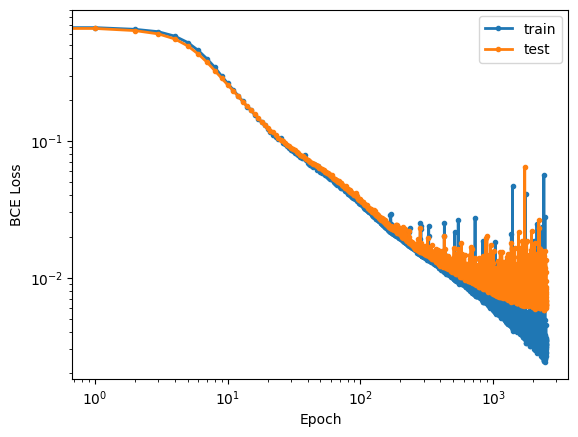

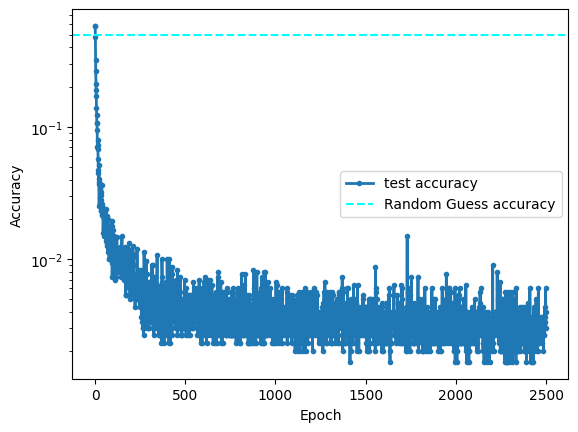

In [21]:
plot_losses(loss_dict["train"], loss_dict["test"])
plot_accuracies(loss_dict['test_acc'])

In [47]:
#print(tensor_nd_test)
#final_result = plot_result(test_data, model)
#final_prediction = predict_bench(test_data, model)
#print(final_result)
prediction = model(test_data)

submision_numpy = prediction.detach().numpy()
submission_df = pd.DataFrame(submision_numpy)
submission = pd.DataFrame({
    "id": range(prediction.shape[0]),
    "prediction": submision_numpy.flatten()})
#submission ['prediction'] = submission ['prediction'] # x8b
#print(submission['prediction'].to_numpy())
#print(tensor_nd_full['y'].cpu().numpy().flatten())
#mape = mape_singular(submission['prediction'].to_numpy(), tensor_nd_full['y'].cpu().numpy().flatten())
#print("Mape")
#print(mape)

#submission = pd.DataFrame({
#    "id": range(len(final_prediction)),
#    "prediction": final_prediction})
#submission ['prediction'] = submission ['prediction'] * x8b

submission.to_csv("predictions.csv", index=False)

print(submission)



          id  prediction
0          0        True
1          1        True
2          2        True
3          3        True
4          4        True
...      ...         ...
44995  44995        True
44996  44996        True
44997  44997        True
44998  44998        True
44999  44999        True

[45000 rows x 2 columns]
